# 3. Setting up the computing environment

In [ ]:
# Installing necessary packages
%pip -q install vina py3Dmol pandas numpy matplotlib 

In [ ]:
# Print versions of vina py3Dmol pandas numpy matplotlib 
import vina
import py3Dmol
import pandas as pd
import numpy as np 
import matplotlib 
from pathlib import Path
from IPython.display import HTML
from vina import Vina



print("Vina version:", vina.__version__)
print("py3Dmol version:", py3Dmol.__version__)
print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)


In [ ]:
# Cloning the course repository
!git clone https://github.com/computationalpharmaceutics/3FG005.git

In [ ]:
# Changing the working directory to
import os
os.chdir('/content/3FG005/Lab_')
!pwd

In [ ]:
from pathlib import Path
import sys


PROJECT_ROOT = Path('Lab_/Docking_Vina/prepared')
WORK_DIR = PROJECT_ROOT / "Docking_Vina"
PREP_DIR = WORK_DIR / "prepared"
RESULTS_DIR = WORK_DIR / "results"

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display



from docking_functions import (
    configure_paths,
    dock_host,
    ensure_host_boxes,
    ensure_prepared_files,
    ensure_published_pose_outputs,
    show_best_pose_grid,
    show_host_pose_interaction_grid,
    show_initial_docking_setup,
    summarize_form_distribution,
)

configure_paths(PREP_DIR, RESULTS_DIR)


In [ ]:
prepared_files = ensure_prepared_files()


,name,pdb,pdbqt,complex_pdb,host_pdb,guest_pdb
0,"5,7-dimethoxyflavone",/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,NaN,NaN,NaN
1,BCD,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,NaN,NaN,NaN
2,HPBCD,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,NaN,NaN,NaN
3,SBEBCD,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,NaN,NaN,NaN
4,57-DMF-BCD_B-form,NaN,NaN,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...
5,57-DMF-BCD_C-form,NaN,NaN,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...
6,57-DMF-HPBCD_B-form,NaN,NaN,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...
7,57-DMF-HPBCD_C-form,NaN,NaN,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...
8,57-DMF-SBEBCD_B-form,NaN,NaN,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...
9,57-DMF-SBEBCD_C-form,NaN,NaN,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...


Loaded ligand PDBQT: /content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML/Docking_Vina/prepared/57-DMF_flex.pdbqt


In [ ]:
HOST_ORDER = ["BCD", "HPBCD", "SBEBCD"]
FORM_ORDER = ["B", "C"]
GUEST_NAME = "5,7-dimethoxyflavone"
PREPARED_INPUT_VERSION = "prepared_folder_loader_v03"
VINA_BOX_SIZE_A = np.array([20.0, 20.0, 20.0], dtype=float)


## Inspect The Unbiased Docking Setup Before Classification

For each host, the viewer below shows the standalone host, the standalone `57-DMF` ligand, and the `20 x 20 x 20 A` Vina box.


In [13]:
HOST_ORDER

['BCD', 'HPBCD', 'SBEBCD']

In [6]:
prepared_files = ensure_prepared_files()
host_boxes, box_table = ensure_host_boxes()

print("Standalone host boxes:")
display(box_table)
print("Vina box size used for every host (A):", VINA_BOX_SIZE_A.tolist())

for host in HOST_ORDER:
    print()
    print(f"Pre-docking setup before B/C classification for {host}")
    display(show_initial_docking_setup(host, prepared_files, host_boxes))


Standalone host boxes:


,host,center_x,center_y,center_z,size_x,size_y,size_z
0,BCD,0.000,-0.000,-0.005,20.0,20.0,20.0
1,HPBCD,5.849,2.372,2.747,20.0,20.0,20.0
2,SBEBCD,9.854,0.012,-14.083,20.0,20.0,20.0


Vina box size used for every host (A): [20.0, 20.0, 20.0]

Pre-docking setup before B/C classification for BCD


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


Pre-docking setup before B/C classification for HPBCD


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


Pre-docking setup before B/C classification for SBEBCD


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Register The Published B-Form And C-Form Pose Snapshots

The published B-form and C-form guest snapshots are loaded from the prepared folder for later qualitative comparison and as the reference geometries used in the post-docking B/C classification step.


In [7]:
published_pose_outputs, published_pose_table = ensure_published_pose_outputs()
display(published_pose_table)


,host,form,published_host_pdb,published_guest_pdb
0,BCD,B,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...
1,BCD,C,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...
2,HPBCD,B,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...
3,HPBCD,C,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...
4,SBEBCD,B,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...
5,SBEBCD,C,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...,/content/drive/MyDrive/00_GITHUB_GD/DOCKING_ML...


## How Vina Calculates The Reported Interaction Energy

Before the docking run, it helps to clarify what AutoDock Vina is actually reporting. In this notebook, the quantity labeled as *Vina interaction energy* is Vina's empirical binding-affinity score in `kcal/mol`, not a full physical decomposition of host-guest interaction energy.

Vina estimates that score in a few broad steps:

1. The host is treated as the receptor and the ligand is placed inside the predefined `20 x 20 x 20 A` search box.
2. Vina samples many trial ligand poses by translating, rotating, and changing ligand torsions within that box.
3. For each sampled pose, Vina evaluates an empirical scoring function that rewards favorable steric fit, hydrophobic contacts, and hydrogen-bond-like interactions, while penalizing steric clashes and ligand flexibility.
4. Vina then locally optimizes promising poses and keeps the best-scoring solutions it finds.
5. The final value reported for each pose, stored in the notebook as `affinity_kcal_mol`, is Vina's estimated binding affinity for that pose. More negative values correspond to more favorable predicted binding.

Later in the notebook, B-like and C-like docked poses are grouped separately, and the **mean Vina interaction energy** for a form is calculated as the arithmetic mean of the Vina affinities of all poses assigned to that form.


## Meaning Of The Pose-Level Analysis Columns

After docking, the notebook builds a pose-level table in which every reported Vina pose is described by both Vina output columns and notebook-derived geometric descriptors. Those columns come from two different sources:

- **Vina-reported quantities**: values read directly from the docked `PDBQT` remarks.
- **Notebook-derived quantities**: values computed afterward from the host and ligand coordinates to classify each pose as B-like or C-like.

### Vina-reported columns

- `rmsd_lb_A`: the **lower-bound RMSD** in A reported by Vina for a pose relative to the **best-ranked pose from the same docking run**. It is not an RMSD to the paper's published B/C structures, and it is not an RMSD to the initial pose. Vina uses a symmetry-aware comparison, so this lower bound is a conservative estimate of how similar the current pose is to the top Vina pose. A value near `0` means the pose is essentially the same docking solution as the best pose, while larger values indicate a more distinct pose family.
- `rmsd_ub_A`: the corresponding **upper-bound RMSD** in A for the same comparison. This is a less conservative estimate than `rmsd_lb_A`, so the true symmetry-aware difference is expected to lie between the lower and upper bounds. In practice, if both `rmsd_lb_A` and `rmsd_ub_A` are small, the pose is very similar to the best Vina pose; if both are large, the pose is geometrically more distinct.

### Notebook-derived B/C classification columns

- `assigned_form`: the notebook's final B/C label for a docked pose. Vina does **not** output this. The notebook assigns it after docking by comparing a two-number geometric descriptor for the docked pose against the corresponding descriptors of the published B-form and C-form reference complexes for the same host.
- `guest_com_axis_A`: the signed axial position of the ligand center of mass, in A, relative to the host center of mass. In the code, the guest center of mass is computed with atomic-mass weighting, the host center of mass is also mass-weighted, and the difference vector is projected onto the host reference axis:
  `dot(guest_com - host_com, axis)`
  A positive or negative sign means the ligand center lies on one side or the other of the host axis origin. The magnitude tells how far the ligand is shifted along the cavity axis.
- `oxygen_minus_carbon_axis_A`: a coarse ligand-orientation descriptor, in A, obtained by first computing the mass-weighted center of all oxygen atoms in the ligand and the mass-weighted center of all carbon atoms in the ligand, then projecting the vector from the carbon center to the oxygen center onto the same host axis:
  `dot(oxygen_com - carbon_com, axis)`
  This does **not** measure a bond length. Instead, it measures whether the oxygen-rich part of the ligand points more toward one end of the host axis and the carbon-rich part points toward the other. A sign flip often indicates a reversed or strongly altered ligand orientation.
- `distance_to_B`: the notebook's normalized Euclidean distance between the docked-pose descriptor vector and the published B-form descriptor vector. The descriptor vector is:
  `[guest_com_axis_A, oxygen_minus_carbon_axis_A]`
  Smaller values mean the docked pose is geometrically more similar to the published B-form reference in this two-descriptor space.
- `distance_to_C`: the same normalized Euclidean distance, but relative to the published C-form reference vector. Smaller values mean the docked pose is geometrically more similar to the published C-form reference.

### How The Notebook Computes The B/C Assignment

The B/C classification is implemented in `classify_docked_modes_by_form(...)` and uses the helper functions `host_axis(...)` and `guest_orientation_descriptor(...)`.

1. **Build the host reference axis.**
   The notebook loads the host `XYZ` coordinates, computes the host mass-weighted center of mass, centers the host coordinates, builds the covariance matrix of the centered coordinates, and takes the eigenvector associated with the **smallest eigenvalue** as the host reference axis. That axis is then normalized to unit length. This gives a simple one-dimensional cavity axis along which both ligand position and ligand orientation can be summarized.

2. **Build B-form and C-form reference descriptors.**
   For the published B-form and C-form complexes of the same host, the notebook computes two numbers for each reference pose:
   - `guest_com_axis_A`
   - `oxygen_minus_carbon_axis_A`

   This gives two reference vectors:
   - `template_vectors["B"] = [guest_com_axis_A, oxygen_minus_carbon_axis_A]` for the published B-form
   - `template_vectors["C"] = [guest_com_axis_A, oxygen_minus_carbon_axis_A]` for the published C-form

3. **Build the same descriptor for each docked pose.**
   The notebook parses each docked mode from the output `PDBQT`, computes the same two descriptor values for that pose, and stores them as:
   - `guest_com_axis_A`
   - `oxygen_minus_carbon_axis_A`

   The docked pose is then represented by:
   - `pose_vector = [guest_com_axis_A, oxygen_minus_carbon_axis_A]`

4. **Normalize the descriptor space.**
   The notebook computes a component-wise scale factor from the absolute difference between the published B and C reference vectors:
   - `scale = maximum(abs(B - C), 1.0)`

   This is important because the two descriptor components may span different numerical ranges. The `maximum(..., 1.0)` safeguard prevents division by very small numbers or zero if the B and C references are very similar in one component.

5. **Compute distances to the B and C references.**
   The notebook then computes:
   - `distance_to_B = norm((pose_vector - template_vectors["B"]) / scale)`
   - `distance_to_C = norm((pose_vector - template_vectors["C"]) / scale)`

   These are normalized Euclidean distances in the two-descriptor space. They are dimensionless comparison scores, not physical energies.

6. **Assign the form by the nearest reference.**
   The final decision rule is:
   - if `distance_to_B <= distance_to_C`, then `assigned_form = "B"`
   - otherwise, `assigned_form = "C"`

   So the pose is assigned to whichever published reference it lies closer to in the normalized two-descriptor space.

### Practical Interpretation

A few consequences are worth keeping in mind:

- `assigned_form` is a **post-docking geometric label**, not a Vina output column.
- `distance_to_B` and `distance_to_C` are **classification distances**, not interaction energies.
- `rmsd_lb_A` and `rmsd_ub_A` only tell you how different a pose is from the **best Vina pose**, not whether it resembles the published B-form or C-form.
- A pose can have a very favorable Vina affinity but still be classified as either B-like or C-like purely from its geometry.
- `%DC` is computed afterward from these assignments as the percentage of docked poses labeled B or C for a given host.


## Redock The Standalone 5,7-DMF Ligand Into Each Host

This is the score-generating docking run. Both the ligand topology and the host structures are loaded directly from the prepared files in `Docking_Vina/prepared`. The search region is a **20 x 20 x 20 A Vina box**, chosen as the closest analogue to the paper's **10 A radius docking sphere**.


In [8]:
prepared_files = ensure_prepared_files()
host_boxes, box_table = ensure_host_boxes()

redocking_outputs = {}
redocking_rows = []

for host in HOST_ORDER:
    center, size = host_boxes[host]
    result = dock_host(host, center, size, exhaustiveness=24, n_poses=20)
    redocking_outputs[host] = result
    redocking_rows.append({
        "host": host,
        "best_docked_affinity_kcal_mol": result["best_docked_affinity_kcal_mol"],
        "best_mode_rmsd_lb_A": result["best_mode_rmsd_lb_A"],
        "best_mode_rmsd_ub_A": result["best_mode_rmsd_ub_A"],
        "n_reported_modes": result["n_reported_modes"],
    })

redocking_scores = pd.DataFrame(redocking_rows).sort_values("host").reset_index(drop=True)
display(redocking_scores.round(3))


,host,best_docked_affinity_kcal_mol,best_mode_rmsd_lb_A,best_mode_rmsd_ub_A,n_reported_modes
0,BCD,-5.728,0.0,0.0,20
1,HPBCD,-5.920,0.0,0.0,20
2,SBEBCD,-6.019,0.0,0.0,20


## Summarize Docked B/C Assignments, %DC, And Interaction Energies


,host,form,%DC,mean_vina_interaction_energy_kcal_mol,best_vina_interaction_energy_kcal_mol,n_poses
0,BCD,B,75.0,-5.274,-5.728,15
1,BCD,C,25.0,-4.910,-5.080,5
2,HPBCD,B,70.0,-5.431,-5.920,14
3,HPBCD,C,30.0,-5.054,-5.108,6
4,SBEBCD,B,95.0,-5.589,-6.019,19
5,SBEBCD,C,5.0,-5.164,-5.164,1


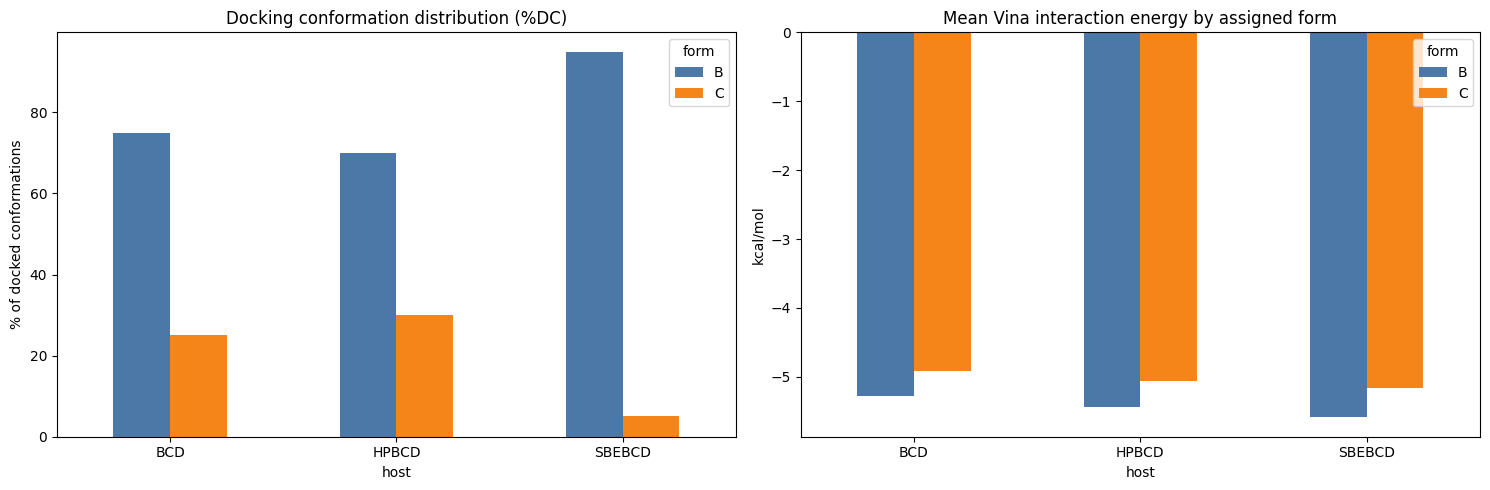


Pose-level assignments for BCD


,host,mode,affinity_kcal_mol,rmsd_lb_A,rmsd_ub_A,assigned_form,guest_com_axis_A,oxygen_minus_carbon_axis_A,distance_to_B,distance_to_C
0,BCD,1,-5.728,0.000,0.000,B,-1.208,-2.134,2.189,2.601
1,BCD,2,-5.673,1.570,3.618,B,-1.212,-2.124,2.180,2.595
2,BCD,3,-5.660,2.290,3.396,B,-1.298,-2.165,2.239,2.674
3,BCD,4,-5.659,1.654,3.668,B,-1.262,-2.117,2.183,2.616
4,BCD,5,-5.657,1.819,2.396,B,-1.219,-2.097,2.155,2.577
5,BCD,6,-5.653,1.788,1.996,B,-1.195,-2.154,2.205,2.610
6,BCD,7,-5.614,2.613,2.901,B,-1.178,-2.104,2.153,2.560
7,BCD,8,-5.224,1.727,2.167,B,-2.010,-1.934,2.293,2.953
8,BCD,9,-5.080,2.633,6.970,C,0.551,1.880,2.202,1.885
9,BCD,10,-5.056,2.018,3.245,B,-1.306,-2.192,2.267,2.701



Pose-level assignments for HPBCD


,host,mode,affinity_kcal_mol,rmsd_lb_A,rmsd_ub_A,assigned_form,guest_com_axis_A,oxygen_minus_carbon_axis_A,distance_to_B,distance_to_C
0,HPBCD,1,-5.920,0.000,0.000,B,-2.036,-2.152,2.643,3.325
1,HPBCD,2,-5.878,1.725,1.837,B,-1.605,-2.104,2.477,3.122
2,HPBCD,3,-5.854,2.341,2.818,B,-1.959,-2.156,2.623,3.297
3,HPBCD,4,-5.838,1.895,3.756,B,-2.039,-2.173,2.662,3.340
4,HPBCD,5,-5.818,2.047,3.711,B,-1.787,-2.143,2.561,3.219
5,HPBCD,6,-5.807,1.790,2.229,B,-1.863,-2.137,2.578,3.246
6,HPBCD,7,-5.730,2.379,3.084,B,-1.790,-2.139,2.559,3.218
7,HPBCD,8,-5.108,3.368,8.071,C,2.219,2.229,2.345,2.245
8,HPBCD,9,-5.107,3.408,7.364,C,2.094,2.265,2.360,2.290
9,HPBCD,10,-5.094,3.335,7.156,B,1.522,2.166,2.195,2.259



Pose-level assignments for SBEBCD


,host,mode,affinity_kcal_mol,rmsd_lb_A,rmsd_ub_A,assigned_form,guest_com_axis_A,oxygen_minus_carbon_axis_A,distance_to_B,distance_to_C
0,SBEBCD,1,-6.019,0.000,0.000,B,3.962,1.987,4.605,5.051
1,SBEBCD,2,-5.997,2.663,2.890,B,3.719,2.071,4.426,4.863
2,SBEBCD,3,-5.961,2.392,3.470,B,4.323,2.163,5.007,5.452
3,SBEBCD,4,-5.905,1.768,1.953,B,4.087,2.123,4.777,5.219
4,SBEBCD,5,-5.823,2.684,4.262,B,3.405,2.072,4.151,4.582
5,SBEBCD,6,-5.805,1.798,3.540,B,3.636,2.167,4.399,4.831
6,SBEBCD,7,-5.734,3.642,7.426,B,0.776,-2.185,2.390,2.626
7,SBEBCD,8,-5.694,2.993,7.170,B,0.972,-2.179,2.471,2.736
8,SBEBCD,9,-5.607,2.797,7.513,B,0.892,-2.208,2.459,2.711
9,SBEBCD,10,-5.592,3.331,7.179,B,0.529,-2.074,2.196,2.401


In [9]:
pose_tables_by_host, form_distribution_summary = summarize_form_distribution(redocking_outputs)
display(form_distribution_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pivot_dc = form_distribution_summary.pivot(index="host", columns="form", values="%DC").loc[HOST_ORDER]
pivot_dc.plot(kind="bar", ax=axes[0], color=["#4c78a8", "#f58518"])
axes[0].set_title("Docking conformation distribution (%DC)")
axes[0].set_ylabel("% of docked conformations")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="form")

pivot_energy = form_distribution_summary.pivot(index="host", columns="form", values="mean_vina_interaction_energy_kcal_mol").loc[HOST_ORDER]
pivot_energy.plot(kind="bar", ax=axes[1], color=["#4c78a8", "#f58518"])
axes[1].set_title("Mean Vina interaction energy by assigned form")
axes[1].set_ylabel("kcal/mol")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="form")

plt.tight_layout()
plt.show()

for host in HOST_ORDER:
    print()
    print(f"Pose-level assignments for {host}")
    display(pose_tables_by_host[host].round(3))


## Visualize All Docked Pose Interactions By Host

Each host is shown as a **1-row-by-2-column interactive grid** after docking: B-form assigned poses on the left and C-form assigned poses on the right. Every panel overlays all docked poses assigned to that form so you can inspect the pose interaction distribution visually.


In [10]:
prepared_files = ensure_prepared_files()

if "pose_tables_by_host" not in globals() or "redocking_outputs" not in globals():
    raise RuntimeError("Run the docking summary cell before visualizing docked pose interactions.")

for host in HOST_ORDER:
    print()
    print(f"All docked pose interactions for {host}")
    display(show_host_pose_interaction_grid(host, prepared_files, pose_tables_by_host, redocking_outputs))



All docked pose interactions for BCD



All docked pose interactions for HPBCD



All docked pose interactions for SBEBCD


## Visualize The Best Pose For Each Host

For each host, the best B-form assigned pose and the best C-form assigned pose are shown in a **1-row-by-2-column interactive grid**.


In [11]:
prepared_files = ensure_prepared_files()

if "pose_tables_by_host" not in globals() or "redocking_outputs" not in globals():
    raise RuntimeError("Run the docking summary cell before visualizing the best poses.")

for host in HOST_ORDER:
    print()
    print(f"Best B/C assigned poses for {host}")
    display(show_best_pose_grid(host, prepared_files, pose_tables_by_host, redocking_outputs))



Best B/C assigned poses for BCD



Best B/C assigned poses for HPBCD



Best B/C assigned poses for SBEBCD


## Where The Input, Output, And Helper Files Live

This V03 notebook reads prepared inputs from:

- `Docking_Vina/prepared/`

writes docking outputs to:

- `Docking_Vina/results/`

and imports user-defined helper functions from:

- `docking_functions.py`

Useful prepared inputs:
- `*_rigid.pdbqt`: rigid host receptors used for docking
- `57-DMF_flex.pdbqt`: flexible ligand input loaded directly for docking
- `57-DMF_from_smiles.pdb`: standalone ligand structure used for pre-docking visualization
- `*_guest.pdb`: published B-form and C-form guest snapshots used for later comparison and B/C classification
- `*_host.pdb`: published host snapshots paired with those guest references

Useful outputs:
- `*_redocked_out.pdbqt`: all docked poses reported by Vina

If you want a more thorough search, rerun the redocking cell with a larger `exhaustiveness`, for example `32` or `64`.
